# Portfolio Analityczne: Dobry Plan
**Stanowisko:** Product Analyst & Tech Support  
**Cel:** Symulacja pracy – od obsługi pojedynczego zgłoszenia do znalezienia błędu w systemie.

## 1. Cel analizy i kontekst
Poniższa analiza opiera się na 1000 wygenerowanych zgłoszeniach od dyrektorów szkół. Jej głównym celem jest znalezienie miejsc, w których zespół wsparcia traci najwięcej czasu oraz zidentyfikowanie najdroższych w obsłudze problemów z platformą.

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt

## 2. Przygotowanie danych (Symulacja)
Aby dane zachowywały się jak w prawdziwym produkcie, celowo zastosowałem w nich konkretne, życiowe proporcje:
* Większość klientów w bazie to mniejsze i średnie szkoły (gigantyczne placówki zdarzają się rzadko).
* Większość zgłoszeń to proste usterki i pytania. Poważne błędy algorytmu (np. *Konflikt sal*) stanowią mniejszość, ale są celowo zaprogramowane jako bardzo czasochłonne w obsłudze.

In [ ]:
# Powtarzalne wyniki pseudo-losowe
np.random.seed()

#Liczba wszystkich przykładowych zgłoszeń
number_of_tickets = 1000

start_date = pd.to_datetime("2025-08-01")

#Daty zgłoszeń
days_to_add = np.random.exponential(scale=45, size=number_of_tickets)
ticket_dates = start_date + pd.to_timedelta(days_to_add, unit="D")

# Rozkład wielkości szkół korzystających z produktu (Log-normal)
school_size = np.random.lognormal(mean=5.5, sigma=0.8, size=number_of_tickets)
school_size = np.clip(school_size, 100, 1500).astype(int)

# Rozkład częstotliwości zgłoszeń z danej kategorii
categories = [
    "Błąd we wczytywaniu danych",
    "Niejasny interfejs",
    "Konflikt sal",
    "Błąd przy logowaniu",
    "Prośba o nową funkcję",
]
probabilities = [0.50, 0.20, 0.15, 0.10, 0.05]
problems = np.random.choice(categories, p=probabilities, size=number_of_tickets)


# Stworzenie ramki danych
df_tickets = pd.DataFrame(
    {
        "ticket_id": range(1, number_of_tickets + 1),
        "ticket_date": ticket_dates,
        "school_size": school_size,
        "category": problems,
    }
)

In [3]:
# Funkcja, która symuluje czas potrzebny na rozwiązanie problemu zgłaszanego przez użytkowników
def simulate_time(row):

    base = {
        "Błąd we wczytywaniu danych": np.random.normal(4, 1), # Typowe problemy, zajmują trochę czasu
        "Niejasny interfejs": np.random.normal(1, 0.5),  # Problemy z interfejsem są łatwe do rozwiązania
        "Konflikt sal": np.random.normal(12, 4),  # Rozwiązanie problemu z konfliktem sal zajmuje znacznie więcej czasu niż inne
        "Błąd przy logowaniu": np.random.normal(0.5, 0.1), # To najłatwiejsze do rozwiązania problemy
        "Prośba o nową funkcję": np.random.normal(24, 8), # Zajęcie się wdrożeniem nowych funkcji może zająć najwięcej czasu
    }[row["category"]]

    coefficient = 1.0 + (row["school_size"] / 2000)

    time = max(0.1, base * coefficient)
    return round(time, 1)


# Funkcja, która symuluje zadowolenie z obsługi supportu względem czasu rozwiązania problemu
def simulate_satisfaction(time):
    if time < 2:
        return np.random.choice([4, 5], p=[0.2, 0.8])
    elif time < 8:
        return np.random.choice([3, 4, 5], p=[0.3, 0.5, 0.2])
    else:
        return np.random.choice([1, 2, 3], p=[0.6, 0.3, 0.1])

In [ ]:
df_tickets = (
    df_tickets.assign(
        time_for_solution_hours=lambda x: x.apply(simulate_time, axis=1),
        satisfaction_rating=lambda x: x["time_for_solution_hours"].apply(
            simulate_satisfaction
        ),
    )
    .sort_values(by="ticket_date")
    .reset_index(drop=True)
)

## 3. Analiza danych (EDA)
W tej sekcji sprawdzamy, ile czasu zespół wsparcia faktycznie poświęca na poszczególne problemy. Zestawiamy tu liczbę konkretnych zgłoszeń z całkowitym czasem potrzebnym na udzielenie pomocy klientom.

In [5]:
df_tickets.sample(5)

,ticket_id,ticket_date,school_size,category,time_for_solution_hours,satisfaction_rating
906,654,2025-11-23 10:07:48.851282962,266,Niejasny interfejs,1.6,5
172,899,2025-08-10 08:26:21.987413298,164,Prośba o nową funkcję,23.2,3
732,634,2025-09-30 06:11:26.708668238,212,Błąd we wczytywaniu danych,4.8,4
404,475,2025-08-26 15:11:18.269499249,363,Błąd we wczytywaniu danych,3.4,4
531,59,2025-09-07 01:11:27.181025612,301,Niejasny interfejs,1.4,5


Jak widać konflikt sal generuje zdecydowanie największy koszt czasowy dla zespołu wsparcia.

In [6]:
df_tickets.groupby("category")["time_for_solution_hours"].sum()

category
Błąd przy logowaniu             55.0
Błąd we wczytywaniu danych    2264.1
Konflikt sal                  2561.5
Niejasny interfejs             243.0
Prośba o nową funkcję         1214.9
Name: time_for_solution_hours, dtype: float64

Jest to nieproporcjonalne względem tego jak często zgłasza się takie problemy - są one cięższe do rozwiązania niż pozostałe zgłoszenia.

In [7]:
df_tickets.groupby("category").size()

category
Błąd przy logowaniu            94
Błąd we wczytywaniu danych    479
Konflikt sal                  181
Niejasny interfejs            200
Prośba o nową funkcję          46
dtype: int64

### Wizualizacja na wykresie

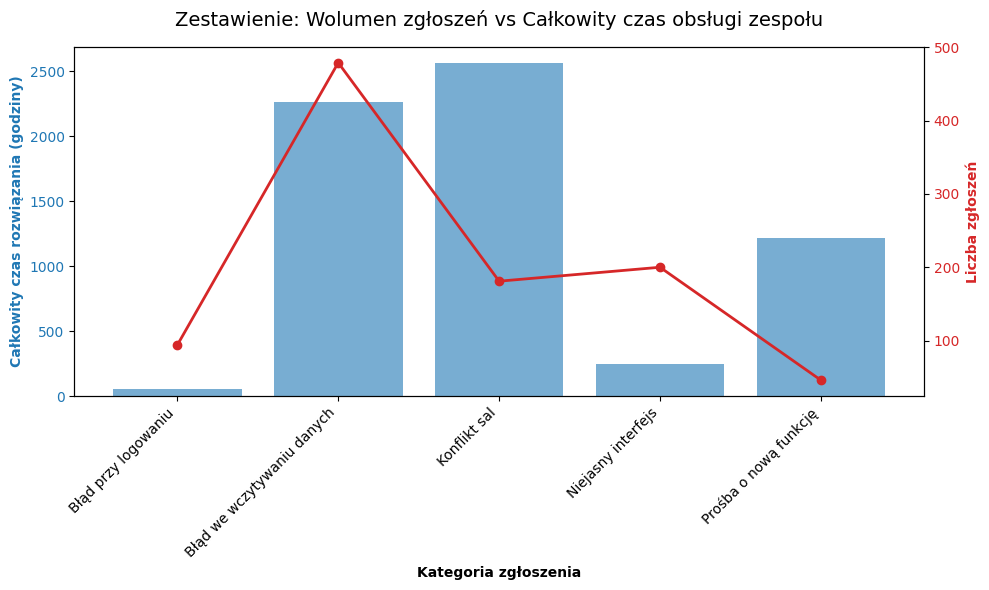

In [9]:
# Zapisanie wyników Twojej agregacji do jednej, czystej ramki danych
aggregation = (
    df_tickets.groupby("category")
    .agg(
        tickets_count=("ticket_id", "count"),
        total_time=("time_for_solution_hours", "sum"),
    )
    .reset_index()
)

# Rysowanie zaawansowanego wykresu z dwiema osiami
fig, ax1 = plt.subplots(figsize=(10, 6))

color = "tab:blue"
ax1.set_xlabel("Kategoria zgłoszenia", fontweight="bold")
ax1.set_ylabel("Całkowity czas rozwiązania (godziny)", color=color, fontweight="bold")
ax1.bar(
    aggregation["category"],
    aggregation["total_time"],
    color=color,
    alpha=0.6,
    label="Czas (h)",
)
ax1.tick_params(axis="y", labelcolor=color)
plt.xticks(rotation=45, ha="right")

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Liczba zgłoszeń", color=color, fontweight="bold")
ax2.plot(
    aggregation["category"],
    aggregation["tickets_count"],
    color=color,
    marker="o",
    linewidth=2,
    label="Liczba ticketów",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Zestawienie: Wolumen zgłoszeń vs Całkowity czas obsługi zespołu",
    fontsize=14,
    pad=15,
)
fig.tight_layout()
plt.show()

## 4. Wnioski i rekomendacje

**Odkrycie:**
Jak pokazuje powyższy wykres, problem `Konflikt sal` to główny "pożeracz czasu". Chociaż to zaledwie około 16% wszystkich zgłoszeń (181 na 1000), to ich ręczne naprawianie przez konsultantów zajmuje zdecydowanie najwięcej czasu – aż ponad 2500 godzin. 

**Proponowane rozwiązania:**
1. **Dla zespołu IT:** Ręczne rozwiązywanie takich konfliktów na dłuższą metę nie ma sensu. Rekomenduję zmianę w algorytmie układającym. Przed ostatecznym wygenerowaniem planu, system musi sprawdzić łączną sumę uczniów przypisanych do danej sali w danym czasie. Jeśli limit miejsc w sali jest przekroczony, system powinien zablokować tę operację, nawet kosztem stworzenia "okienka" dla nauczyciela. Fizyczna pojemność budynku musi mieć wyższy priorytet.
2. **Dla Zespołu Wsparcia:** Zanim programiści wdrożą poprawkę, dział wsparcia powinien mieć gotową procedurę obchodzenia tego problemu. Kiedy dyrektor zgłasza przepełnioną salę, konsultant powinien poinstruować go, jak ręcznie przenieść jedną z klas na inne miejsce w systemie (np. "Korytarz" lub "Boisko"). To zdejmie blokadę z algorytmu i pozwoli dyrektorowi natychmiast opublikować poprawny plan dla reszty szkoły.